# **Câu 1. Liệu thói quen sinh hoạt có ảnh hưởng gì đến khả năng mắc bệnh trầm cảm không?**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_style("whitegrid")

# Load dữ liệu
local_path = "../data_cleaned.csv"
remote_path = "https://raw.githubusercontent.com/phamhuongtra/depression_analysis/refs/heads/format/data/data_cleaned.csv"

try:
    df = pd.read_csv(local_path)
except FileNotFoundError:
    df = pd.read_csv(remote_path)
    
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140610 entries, 0 to 140609
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140610 non-null  int64  
 1   Name                                   140610 non-null  object 
 2   Gender                                 140610 non-null  object 
 3   Age                                    140610 non-null  int64  
 4   City                                   140610 non-null  object 
 5   Working Professional or Student        140610 non-null  object 
 6   Profession                             140610 non-null  object 
 7   Academic Pressure                      140610 non-null  float64
 8   Work Pressure                          140610 non-null  float64
 9   CGPA                                   140610 non-null  float64
 10  Study Satisfaction                     140610 non-null  

Các yếu tố được xem xét bao gồm:
- Thói quen ăn uống (Dietary Habits)
- Thời gian làm việc/học tập (Work/Study Hours)
- Thời lượng ngủ (Sleep Duration)

### Câu hỏi nhỏ
1. Phân tích từng yếu tố đơn lẻ
    - Thói quen ăn uống có làm tăng nguy cơ trầm cảm không?

    - Số giờ làm/học có liên quan đến trầm cảm không?
    
    - Thời lượng ngủ ảnh hưởng thế nào đến trầm cảm?

2. Phân tích hai yếu tố kết hợp
    - Sự kết hợp hai yếu tố sinh hoạt mang lại nguy cơ mắc bệnh Trầm cảm (Depression) lớn hơn đáng kể so với tác động độc lập không?

3. Phân tích ba yếu tố kết hợp
    - Càng nhiều thói quen xấu thì nguy cơ trầm cảm có càng cao không?

## **1. Phân tích từng yếu tố đơn lẻ**

### **Câu 1: Thói quen ăn uống có làm tăng nguy cơ trầm cảm không?**

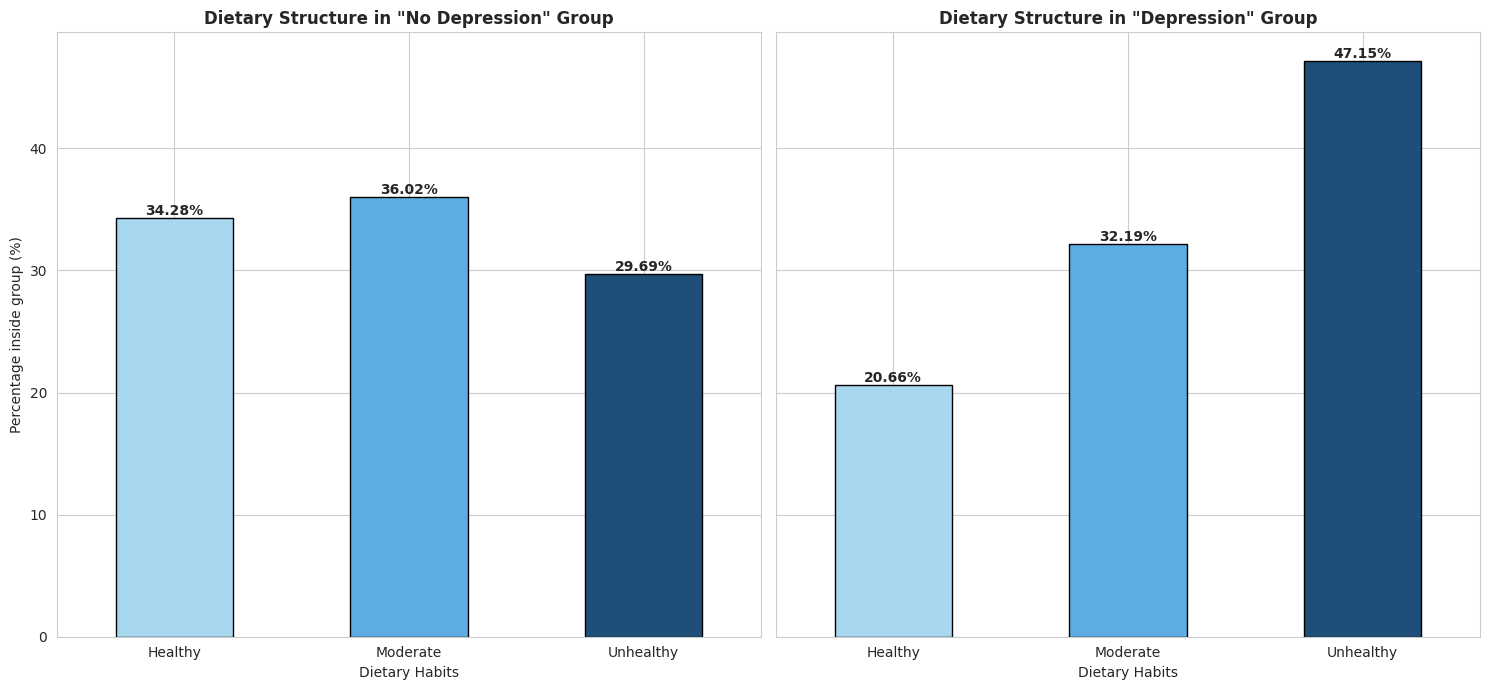

In [3]:
# 1. Tính toán cấu trúc chế độ ăn trong từng nhóm (Normalize theo cột Depression)
diet_structure = pd.crosstab(df['Dietary Habits'], df['Depression'], normalize='columns') * 100
diet_structure.columns = ['No Depression Group', 'Depression Group']

# Sắp xếp thứ tự từ Healthy -> Unhealthy
order = ['Healthy', 'Moderate', 'Unhealthy']
diet_structure = diet_structure.reindex(order)

# 2. Vẽ biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

# Biểu đồ cho nhóm Không trầm cảm
diet_structure['No Depression Group'].plot(kind='bar', ax=ax1, color=['#A7D8F0', '#5DADE2', '#1F4E79'], edgecolor='black')
ax1.set_title('Dietary Structure in "No Depression" Group', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage inside group (%)')
ax1.tick_params(axis='x', rotation=0)

# Biểu đồ cho nhóm Trầm cảm
diet_structure['Depression Group'].plot(kind='bar', ax=ax2, color=['#A7D8F0', '#5DADE2', '#1F4E79'], edgecolor='black')
ax2.set_title('Dietary Structure in "Depression" Group', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=0)

for ax in [ax1, ax2]:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('h1.png')
plt.show()

#### Nhận xét
- Trong nhóm không trầm cảm, tỷ lệ người có chế độ ăn Healthy và Moderate chiếm phần lớn (lần lượt khoảng 34.28% và 36.02%), trong khi tỷ lệ Unhealthy thấp hơn (29.69%). Điều này cho thấy nhóm này có xu hướng duy trì chế độ ăn uống cân bằng và lành mạnh hơn.

- Ngược lại, trong nhóm trầm cảm, tỷ lệ người có chế độ ăn Unhealthy tăng lên đáng kể (47.15%), cao hơn nhiều so với hai nhóm còn lại. Đồng thời, tỷ lệ Healthy giảm xuống còn khoảng 20.66%.

#### Kết luận
Chế độ ăn kém lành mạnh có thể liên quan đến nguy cơ trầm cảm cao hơn, trong khi việc duy trì chế độ ăn lành mạnh có thể góp phần giảm nguy cơ này.

## **Câu 2: Số giờ làm/học có liên quan đến trầm cảm không?**
Work/Study Hours được chia thành các khoảng giá trị để dễ phân tích và so sánh. Cụ thể:
- 0–5 giờ → Low

- 5–8 giờ → Medium

- 8–12 giờ → High

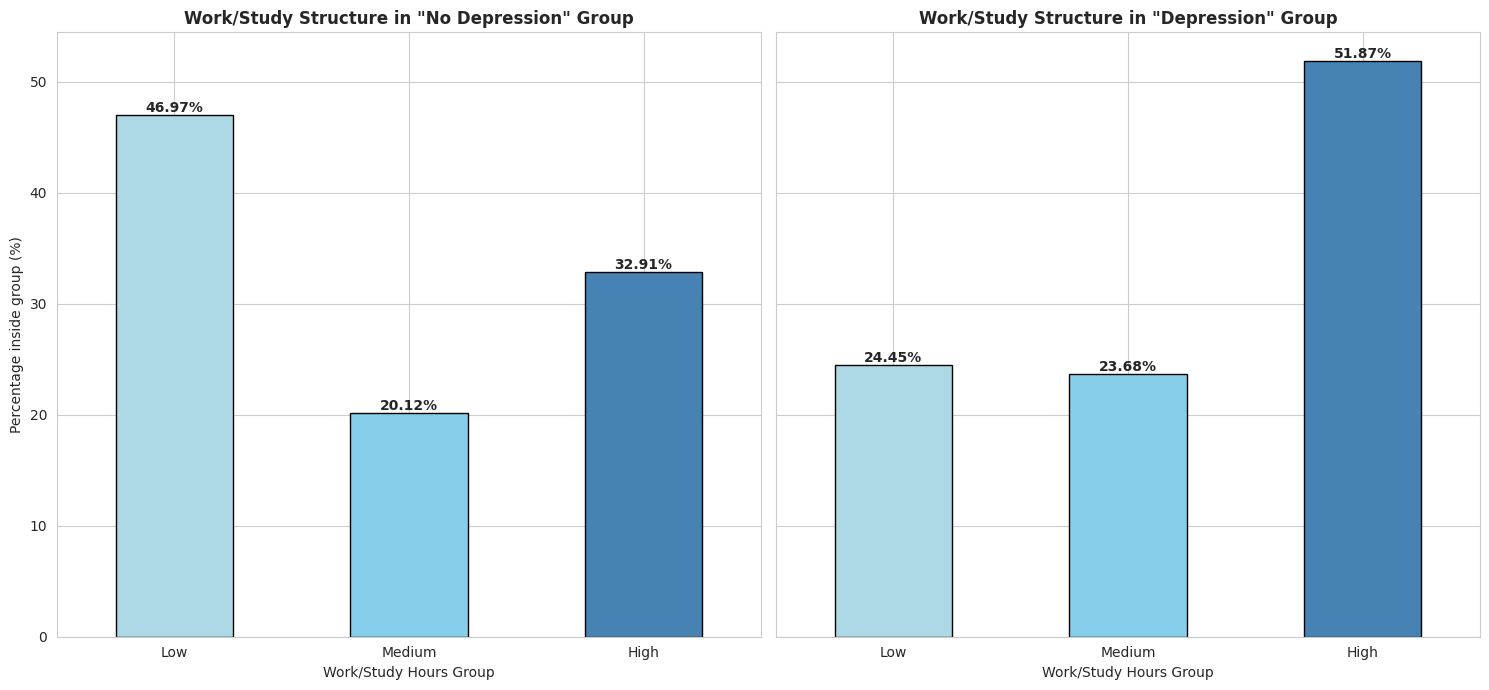

In [4]:
# 1. Phân nhóm Work/Study Hours
bins = [0, 5, 8, 12]
labels = ['Low', 'Medium', 'High']
df['Work/Study Hours Group'] = pd.cut(
    df['Work/Study Hours'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# 2. Tính toán cấu trúc TRONG NỘI BỘ từng nhóm Depression
work_structure = pd.crosstab(df['Work/Study Hours Group'], df['Depression'], normalize='columns') * 100
work_structure.columns = ['No Depression Group', 'Depression Group']

work_structure = work_structure.reindex(['Low', 'Medium', 'High'])

# 3. Vẽ biểu đồ side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

colors = ['#add8e6', '#87ceeb', '#4682b4']

# Biểu đồ cho nhóm Không trầm cảm
work_structure['No Depression Group'].plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_title('Work/Study Structure in "No Depression" Group', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage inside group (%)')
ax1.tick_params(axis='x', rotation=0)

# Biểu đồ cho nhóm Trầm cảm
work_structure['Depression Group'].plot(kind='bar', ax=ax2, color=colors, edgecolor='black')
ax2.set_title('Work/Study Structure in "Depression" Group', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=0)

for ax in [ax1, ax2]:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('h2.png')
plt.show()

#### Nhận xét
- Trong nhóm không trầm cảm, phần lớn cá nhân thuộc nhóm Low work/study hours (khoảng 46.97%), trong khi nhóm High hours chiếm 32.91% và Medium hours chiếm tỷ lệ thấp hơn (20.12%). Điều này cho thấy những người không bị trầm cảm có xu hướng dành ít thời gian hơn cho công việc hoặc học tập.

- Ngược lại, trong nhóm trầm cảm, tỷ lệ người thuộc nhóm High work/study hours tăng lên đáng kể (51.87%), cao hơn nhiều so với nhóm Low (24.45%) và Medium (23.68%).
#### Kết luận
Việc dành quá nhiều thời gian cho học tập hoặc công việc có thể liên quan đến nguy cơ trầm cảm cao hơn, trong khi việc duy trì khối lượng công việc/học tập ở mức hợp lý có thể giúp giảm nguy cơ này.


## **Câu 3: Thời lượng ngủ ảnh hưởng thế nào đến trầm cảm?**
Trong đó cột Sleep Duration được chia thành các khoảng giá trị để dễ phân tích và so sánh. Cụ thể:
- 0–4 giờ → 1

- 4–6 giờ → 2

- 6–8 giờ → 3

- 7–9 giờ → 4

- (>9) giờ  → 5

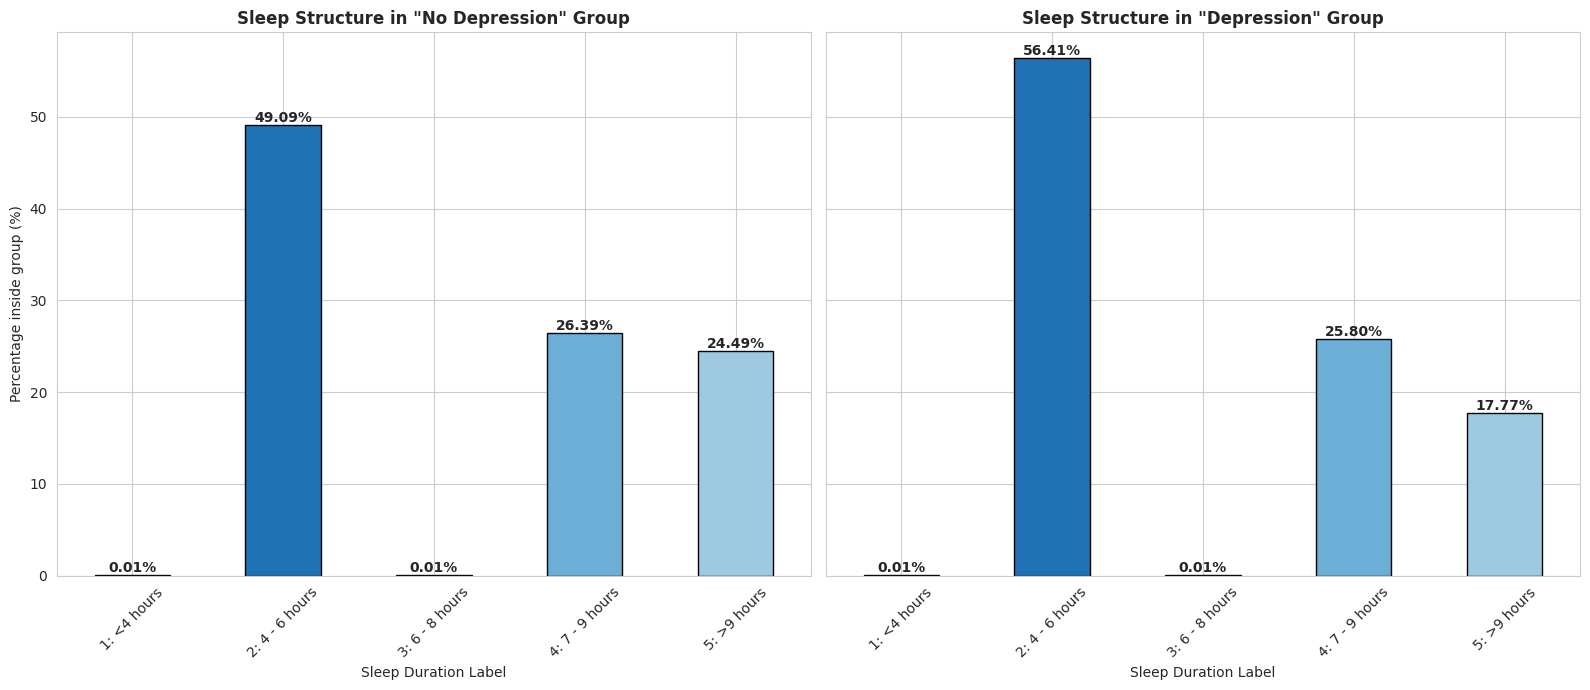

In [5]:
# 1. Mapping và chuẩn bị dữ liệu
sleep_labels = {
    1: "1: <4 hours",
    2: "2: 4 - 6 hours",
    3: "3: 6 - 8 hours",
    4: "4: 7 - 9 hours",
    5: "5: >9 hours"
}
df['Sleep Duration Label'] = df['Sleep Duration'].map(sleep_labels)
order = list(sleep_labels.values())

# 2. Tính toán cấu trúc nội bộ (Normalize theo cột Depression)
sleep_structure = pd.crosstab(df['Sleep Duration Label'], df['Depression'], normalize='columns') * 100
sleep_structure.columns = ['No Depression Group', 'Depression Group']
sleep_structure = sleep_structure.reindex(order)

# 3. Vẽ biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

colors = ['#084594', '#2171b5', '#4292c6', '#6baed6', '#9ecae1']

# Biểu đồ cho nhóm Không trầm cảm
sleep_structure['No Depression Group'].plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_title('Sleep Structure in "No Depression" Group', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage inside group (%)')
ax1.tick_params(axis='x', rotation=45)

# Biểu đồ cho nhóm Trầm cảm
sleep_structure['Depression Group'].plot(kind='bar', ax=ax2, color=colors, edgecolor='black')
ax2.set_title('Sleep Structure in "Depression" Group', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

for ax in [ax1, ax2]:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('h3.png')
plt.show()

#### Nhận xét
- Biểu đồ cho thấy cấu trúc thời gian ngủ giữa hai nhóm có và không có trầm cảm có sự khác biệt nhưng mà không quá lớn.

- Trong cả hai nhóm, phần lớn cá nhân ngủ 4–6 giờ mỗi ngày, nhưng tỷ lệ này cao hơn ở nhóm trầm cảm (56.41% so với 49.09%). Ngược lại, nhóm không trầm cảm có tỷ lệ ngủ trên 9 giờ cao hơn (24.49% so với 17.77%)
#### Kết luận
Việc ngủ không đủ giấc có thể liên quan đến nguy cơ trầm cảm cao nhưng mà không phải là nhân tố quyết định.


#### **Kết luận phần 1**
Khi xem xét tổng thể các yếu tố như chế độ ăn uống, thời gian học tập/làm việc và thời lượng ngủ, có thể thấy rằng nhóm trầm cảm thường có xu hướng gắn với các thói quen kém lành mạnh hơn, chẳng hạn như ăn uống không điều độ, làm việc hoặc học tập quá nhiều, và ngủ không đủ giấc.

Tuy nhiên, mức độ khác biệt giữa nhóm người bị trầm cảm và nhóm người không bị trầm cảm không quá lớn. Điều này cho thấy mỗi yếu tố riêng lẻ chỉ có tác động nhất định đến nguy cơ trầm cảm.

Do đó, trầm cảm nhiều khả năng không xuất phát từ một nguyên nhân đơn lẻ mà là kết quả của sự kết hợp giữa nhiều yếu tố về lối sống và thói quen sinh hoạt.


## **2. Phân tích hai yếu tố kết hợp**

### **Câu 4: Sự kết hợp hai yếu tố sinh hoạt mang lại nguy cơ mắc bệnh Trầm cảm (Depression) lớn hơn đáng kể so với tác động độc lập không?**

Mục tiêu của phân tích này là kiểm tra xem sự kết hợp giữa các cặp thói quen sinh hoạt bao gồm: thời lượng ngủ (Sleep Duration), số giờ làm việc/học tập (Work/Study Hours) và thói quen ăn uống (Dietary Habits) có tạo ra tác động cộng hưởng đến tình trạng trầm cảm (Depression).

Liệu những người làm việc/học tập với cường độ cao, kết hợp với việc thiếu ngủ và ăn uống không lành mạnh, thì nguy cơ rơi vào trầm cảm có tăng vọt (hiệu ứng khuếch đại) so với khi họ chỉ mắc phải một trong những thói quen xấu này hay không?

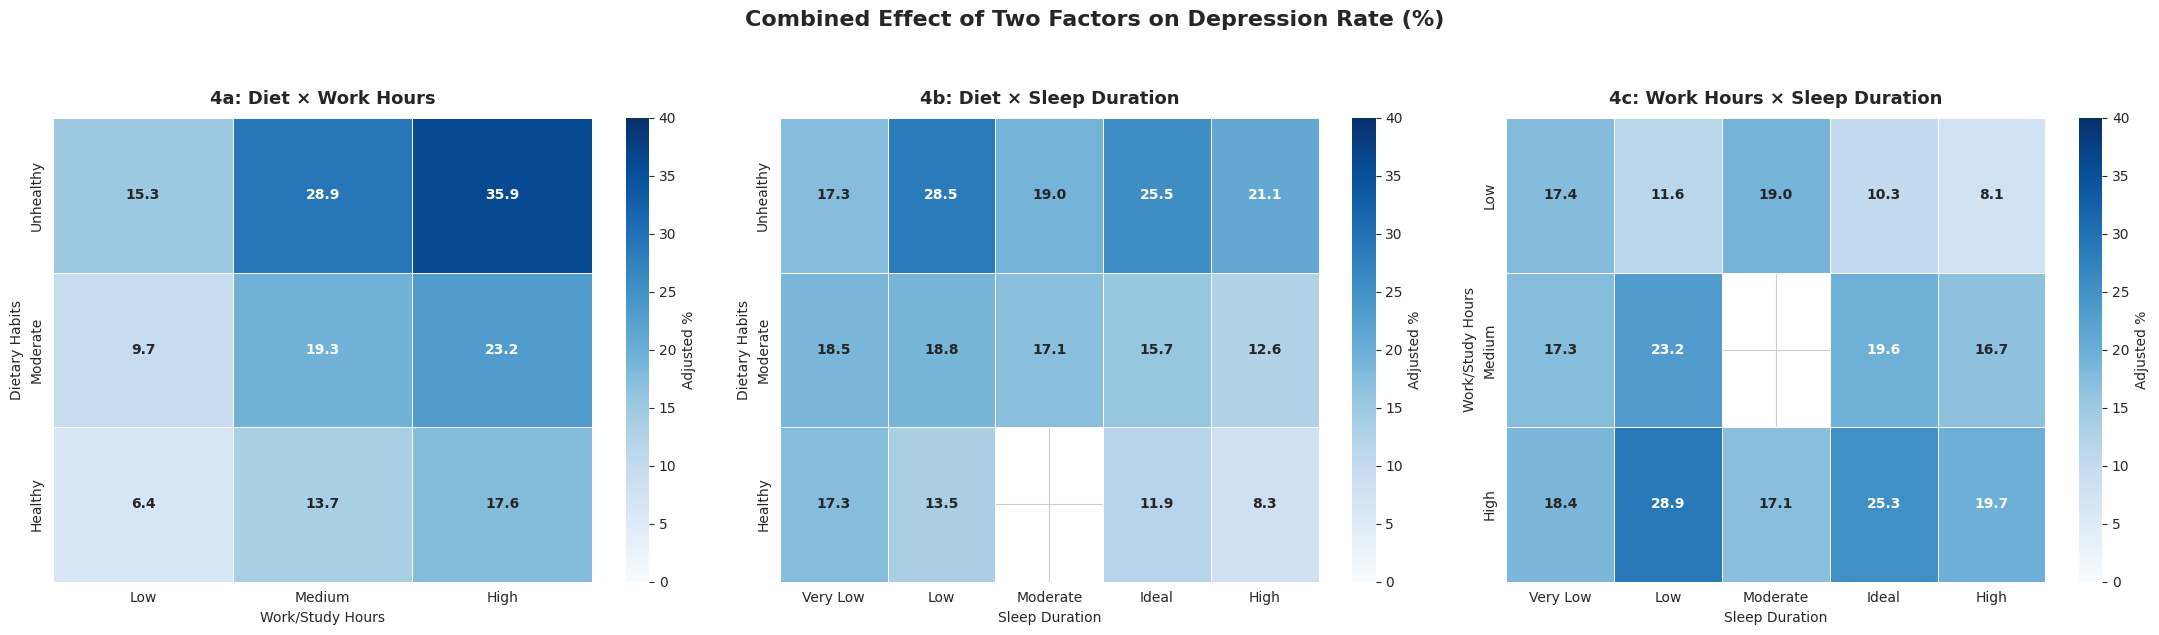

In [6]:
# 1. Phân nhóm Work/Study Hours
df['WSH_group'] = pd.cut(df['Work/Study Hours'], bins=[-1, 5, 8, 12], labels=['Low', 'Medium', 'High'])

sleep_labels = {1: 'Very Low', 2: 'Low', 3: 'Moderate', 4: 'Ideal', 5: 'High'}
df['Sleep_label'] = df['Sleep Duration'].map(sleep_labels)

global_mean = df['Depression'].mean()
m = 100
def smoothed_mean(series):
    return (series.sum() + m * global_mean) / (series.count() + m) * 100

# 2. Gom nhóm dữ liệu
diet_order  = ['Unhealthy', 'Moderate', 'Healthy']
wsh_order   = ['Low', 'Medium', 'High']
sleep_order = ['Very Low', 'Low', 'Moderate', 'Ideal', 'High']

pivot_4a = df.groupby(['Dietary Habits', 'WSH_group'], observed=True)['Depression'].agg(smoothed_mean).unstack().reindex(index=diet_order, columns=wsh_order)
pivot_4b = df.groupby(['Dietary Habits', 'Sleep_label'], observed=True)['Depression'].agg(smoothed_mean).unstack().reindex(index=diet_order, columns=sleep_order)
pivot_4c = df.groupby(['WSH_group', 'Sleep_label'], observed=True)['Depression'].agg(smoothed_mean).unstack().reindex(index=wsh_order, columns=sleep_order)
pivot_counts = df.groupby(['Dietary Habits', 'WSH_group'], observed=True).size().unstack().reindex(index=diet_order, columns=wsh_order)

# 3. Vẽ biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Combined Effect of Two Factors on Depression Rate (%)', fontsize=16, fontweight='bold', y=1.05)

def draw_hmap(ax, data, title, xlabel, ylabel):
    sns.heatmap(data, annot=True, fmt='.1f', cmap='Blues',
                vmin=0, vmax=40, linewidths=0.5, linecolor='white',
                ax=ax, annot_kws={'size': 10, 'weight': 'bold'},
                cbar_kws={'label': 'Adjusted %'})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

draw_hmap(axes[0], pivot_4a, '4a: Diet × Work Hours', 'Work/Study Hours', 'Dietary Habits')
draw_hmap(axes[1], pivot_4b, '4b: Diet × Sleep Duration', 'Sleep Duration', 'Dietary Habits')
draw_hmap(axes[2], pivot_4c, '4c: Work Hours × Sleep Duration', 'Sleep Duration', 'Work/Study Hours')

plt.tight_layout()
plt.savefig('h4.png')
plt.show()

#### Nhận xét
Các biểu đồ heatmap cho thấy tỷ lệ trầm cảm luôn đạt mức cao nhất khi các thói quen sinh hoạt tiêu cực xuất hiện cùng lúc:
- Biểu đồ 4a (Ăn uống × Giờ làm/học):  Nhóm có chế độ ăn kém (Unhealthy) và cường độ làm việc cao (High) có tỷ lệ trầm cảm cực kỳ cao, lên tới 35.9%. Ngược lại, nhóm có lối sống lành mạnh nhất (ăn Healthy, làm việc Low) chỉ ở mức 6.4%.
- Biểu đồ 4b (Ăn uống × Giờ ngủ): Sự kết hợp giữa chế độ ăn Unhealthy và thời lượng ngủ Thấp đẩy rủi ro trầm cảm lên mức 28.5%. Trong khi đó, người ăn Healthy và ngủ Cao chỉ ghi nhận tỷ lệ 8.3%.
- Biểu đồ 4c (Giờ làm/học × Giờ ngủ): Nhóm người vắt kiệt sức với cường độ làm việc High nhưng ngủ Thấp có tỷ lệ trầm cảm là 28.9%, cao gần gấp 3 lần so với những người làm việc cường độ Low và ngủ Lý tưởng (chỉ 10.3%).

#### **Kết luận phần 2**
Sự kết hợp giữa hai yếu tố sinh hoạt xấu mang lại rủi ro mắc bệnh Trầm cảm lớn hơn đáng kể so với tổng các tác động độc lập. Các thói quen này không hoạt động riêng lẻ, mà chúng tương tác và làm trầm trọng thêm hậu quả của nhau đẩy người bệnh vào nguy cơ suy sụp tinh thần với tỷ lệ cao.

## **3. Phân tích ba yếu tố kết hợp**

### **Câu 5: Càng nhiều thói quen xấu thì nguy cơ trầm cảm có càng cao không?**

Mục tiêu của phân tích này là kiểm tra xem số lượng thói quen sinh hoạt không lành mạnh (Bad Habits)
có ảnh hưởng đến tình trạng trầm cảm (Depression) hay không.

Trong phân tích này, thói quen xấu được xác định dựa trên ba yếu tố trong dữ liệu:

- Ngủ quá ít (Sleep Duration ≤ mức thấp, tương ứng dưới khoảng 6 giờ).

- Thời gian học tập/làm việc cao (Work/Study Hours = High).

- Chế độ ăn uống không lành mạnh (Dietary Habits = Unhealthy).

Phân tích này nhằm trả lời câu hỏi: **Liệu khi số lượng thói quen xấu tăng lên, nguy cơ mắc trầm cảm có tăng theo hay không?**

,Number of Bad Habits,No Depression,Depression
0,0,87.757288,12.242712
1,1,81.342534,18.657466
2,2,71.440269,28.559731


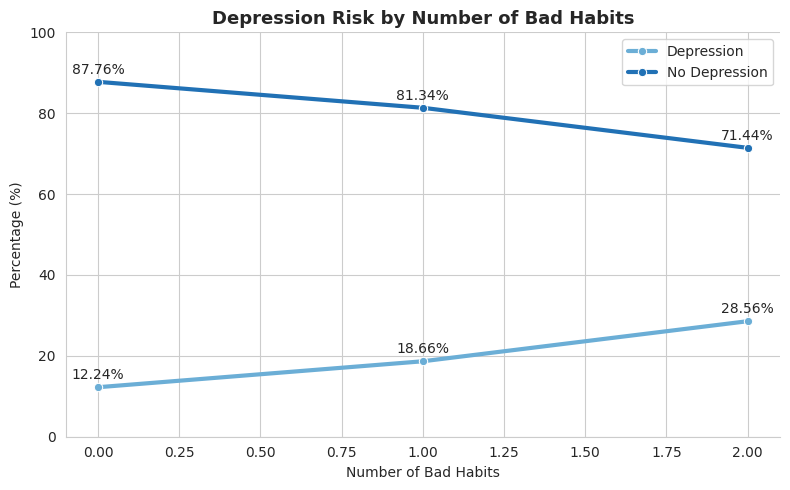

In [7]:
# 1. Tạo các biến thói quen xấu
df['bad_sleep'] = (df['Sleep Duration'] <= 2).astype(int)
df['bad_work'] = (df['Work/Study Hours'] == 'High').astype(int)
df['bad_diet'] = (df['Dietary Habits'] == 'Unhealthy').astype(int)

df['bad_habits_count'] = (
    df['bad_sleep'] +
    df['bad_work'] +
    df['bad_diet']
)

# 2. Tính tỷ lệ % trầm cảm trong mỗi mức thói quen xấu
habit_analysis = pd.crosstab(
    df['bad_habits_count'],
    df['Depression'],
    normalize='index'
) * 100

habit_analysis = habit_analysis.reset_index()
habit_analysis.columns = ['Number of Bad Habits','No Depression','Depression']

display(habit_analysis)

# 3. Vẽ biểu đồ
plt.figure(figsize=(8,5))

# Line cho Depression
sns.lineplot(
    data=habit_analysis,
    x='Number of Bad Habits',
    y='Depression',
    marker='o',
    linewidth=3,
    color='#6baed6',
    label='Depression'
)

# Line cho No Depression
sns.lineplot(
    data=habit_analysis,
    x='Number of Bad Habits',
    y='No Depression',
    marker='o',
    linewidth=3,
    color='#2171b5',
    label='No Depression'
)

# 4. Thêm % trên từng điểm
for x, y in zip(habit_analysis['Number of Bad Habits'], habit_analysis['Depression']):
    plt.text(x, y + 2, f'{y:.2f}%', ha='center', fontsize=10)

for x, y in zip(habit_analysis['Number of Bad Habits'], habit_analysis['No Depression']):
    plt.text(x, y + 2, f'{y:.2f}%', ha='center', fontsize=10)

plt.title('Depression Risk by Number of Bad Habits', fontsize=13, fontweight='bold')
plt.xlabel('Number of Bad Habits')
plt.ylabel('Percentage (%)')
plt.ylim(0,100)

sns.despine()

plt.tight_layout()
plt.savefig('h5.png')
plt.show()

#### Nhận xét

Hai đường trong biểu đồ thể hiện xu hướng nghịch chiều rõ ràng giữa tỷ lệ trầm cảm và không trầm cảm khi số lượng thói quen xấu tăng lên. Khi không có thói quen xấu, tỷ lệ trầm cảm chỉ 12.24%, trong khi tỷ lệ không trầm cảm chiếm 87.76%.

Khi xuất hiện 1 thói quen xấu, tỷ lệ trầm cảm tăng lên 18.66%, đồng thời tỷ lệ không trầm cảm giảm xuống 81.34%. Xu hướng này tiếp tục rõ hơn khi số thói quen xấu tăng lên 2, với tỷ lệ trầm cảm đạt 28.56% và tỷ lệ không trầm cảm giảm còn 71.44%.
#### **Kết luận phần 3**
Khi các thói quen sinh hoạt không lành mạnh tích lũy nhiều hơn, nguy cơ trầm cảm có xu hướng tăng lên, trong khi tỷ lệ không trầm cảm giảm dần.

## **Kết luận tổng thể**

Kết quả phân tích cho thấy **các thói quen sinh hoạt có mối liên hệ nhất định với nguy cơ trầm cảm**.

Khi xem xét từng yếu tố riêng lẻ, mức độ khác biệt không quá lớn. Ta thấy những người có **chế độ ăn uống kém lành mạnh, thời gian làm việc/học tập cao hoặc thời lượng ngủ không phù hợp** thường làm tăng **tỷ lệ trầm cảm** mặc dù không đáng kể so với nhóm người không bị trầm cảm.

Tuy nhiên, khi **nhiều thói quen xấu xuất hiện đồng thời**, tỷ lệ trầm cảm **tăng rõ rệt**. Điều này cho thấy sự kết hợp của nhiều thói quen sinh hoạt không lành mạnh có thể làm gia tăng nguy cơ trầm cảm mạnh hơn so với từng yếu tố riêng lẻ.
